<a href="https://colab.research.google.com/github/avaniichhabra/Netflix-movie-analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

  import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visual style
sns.set_style('whitegrid')

# Read the dataset
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

# Display first few rows
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [2]:
# Check the structure and types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [3]:
# Convert to datetime format
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

# Extract only the year from date
df['Release_Date'] = df['Release_Date'].dt.year

# Confirm the changes
df['Release_Date'].head()

,Release_Date
0,2021
1,2022
2,2022
3,2021
4,2021


In [4]:
# Remove columns not useful for our analysis
cols_to_drop = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(columns=cols_to_drop, inplace=True)

# Check remaining columns
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [5]:
def categorize_column(df, col, labels):
    edges = [df[col].min(),
             df[col].quantile(0.25),
             df[col].quantile(0.5),
             df[col].quantile(0.75),
             df[col].max()]

    df[col] = pd.cut(df[col], bins=edges, labels=labels, duplicates='drop')
    return df

# Apply the function to 'Vote_Average'
labels = ['not_popular', 'below_avg', 'average', 'popular']
df = categorize_column(df, 'Vote_Average', labels)

# Drop any rows with missing values (if any)
df.dropna(inplace=True)

# Confirm the unique categories
df['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2412
below_avg,2398


In [6]:
# Split the string into list
df['Genre'] = df['Genre'].str.split(', ')

# Explode the list to get one genre per row
df = df.explode('Genre').reset_index(drop=True)

# Convert genre to category type
df['Genre'] = df['Genre'].astype('category')

# Final dataset shape and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


The most frequent Genre :

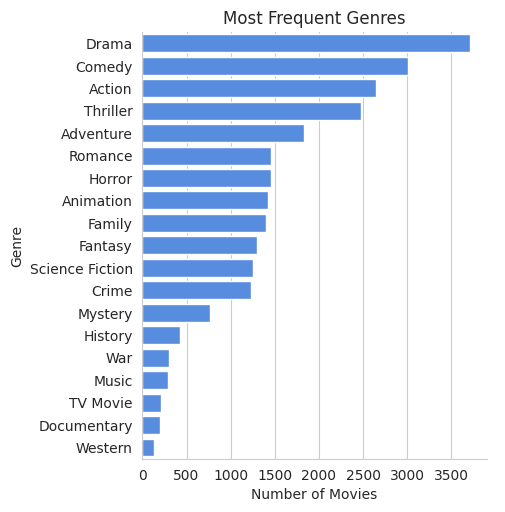

In [7]:
# Display genre frequency
df['Genre'].describe()

# Visualize genre distribution
sns.catplot(y='Genre', data=df, kind='count', order=df['Genre'].value_counts().index, color='#4287f5')
plt.title('Most Frequent Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

The most frequent genre is drama.

Category(popular/ average) with the most movies :

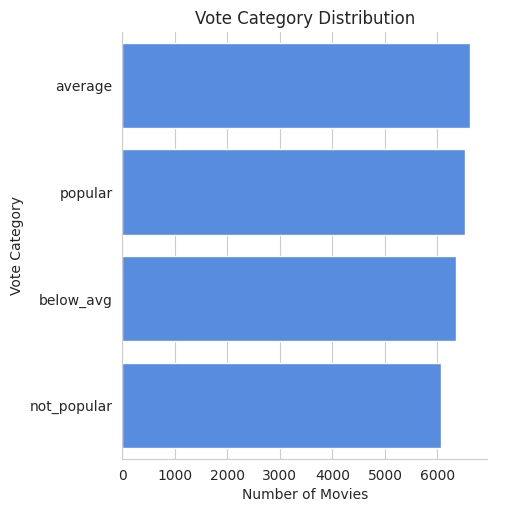

In [9]:
sns.catplot(y='Vote_Average', data=df, kind='count', order=df['Vote_Average'].value_counts().index, color='#4287f5')
plt.title('Vote Category Distribution')
plt.xlabel('Number of Movies')
plt.ylabel('Vote Category')
plt.show()


Most movies fall into the popular categories followed by below_avg.

Most and least popular movies :

In [12]:
# Highest popularity movie(s)
df[df['Popularity'] == df['Popularity'].max()]

# Lowest popularity movie(s)
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


Highest popular movie : Spider-Man: No Way Home
Least popular movie : The United States vs. Billie Holiday



Year with the most movies :

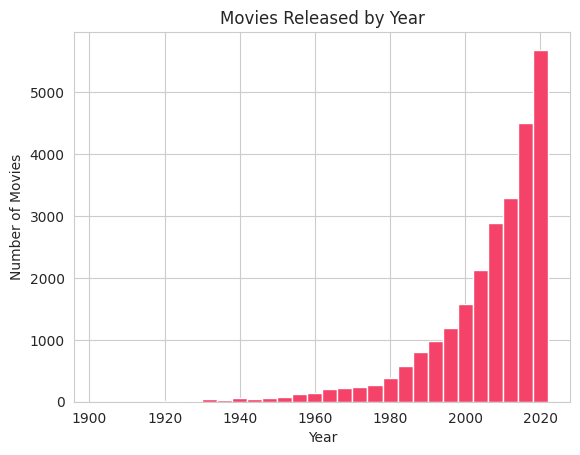

In [11]:
df['Release_Date'].hist(bins=30, color='#f54269')
plt.title('Movies Released by Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

Year with the most movies is 2020.